# Verifying a neural network: a triage model

**Neural network verification, hands-on.** ACM Europe Seasonal School on Responsible AI · Aston University · September 2026 · Luca Arnaboldi (University of Birmingham). *Notebook 1 of 2 · about 35 minutes · nothing to install.*

Testing a neural network tells you about the inputs you tried. **Verification** tells you about the inputs you did not: a verifier either *proves* that a property holds for **every** input in a region, or it hands you a concrete **counterexample**. In this notebook you will:

1. meet a small neural network that turns a patient's vital signs into an urgency class (low / medium / high);
2. state clinical hard limits as **properties** and ask a verifier whether they hold for *every* plausible patient;
3. watch a 96 %-accurate model fail, read the failing patient in clinical units, see a better model still fail at a corner, and see a third model prove every property;
4. probe robustness to measurement noise, edit a specification yourself, and export the property to the tool-neutral VNN-LIB format;
5. take the results to the debate: what should "robust enough" mean, and who decides?

> **Everything here is synthetic and educational.** The labelling rule is borrowed from the NHS National Early Warning Score 2 (Royal College of Physicians, 2017; Scale 1 only, no age or pregnancy adjustments) to make the properties feel real. The data are generated, the model is a toy, and nothing in this notebook is a clinical tool.

**Tools.** The specification language is [Vehicle](https://vehicle-lang.github.io/tutorial/) (you write properties in the problem's own units; it compiles them for the solver), the solver is [Marabou](https://github.com/NeuralNetworkVerification/Marabou), and the network format is ONNX. The same property compiles to [VNN-LIB](https://www.vnnlib.org/), the format every tool in the annual verification competition reads, so nothing here is tied to one tool.

## 0 · Setup (2–3 minutes)

Run the cell below once. It fetches the materials, creates a Python 3.11 environment with the verifier (Colab's own Python is too new for the solver's wheels), and prints `OK`. If Colab restarts the runtime, just run it again.

**Expected output:** the working directory, a few bootstrap lines, then `vehicle 0.27.1 | Marabou at /content/venv/bin/Marabou` and `OK - ready.`

In [1]:
# --- Setup (idempotent; safe to re-run) -------------------------------------------------------------
# Colab's kernel is Python 3.12 and the Marabou solver only ships wheels for Python 3.8-3.11 (x86_64),
# so the toolchain lives in a separate Python 3.11 environment created by environment/colab_bootstrap.sh.
# We never import the verifier into this kernel; we call the `vehicle` command-line tool.
import os, sys, subprocess, pathlib, shutil, time

REPO_URL = "https://github.com/Yiergot/acaira-2026-nn-verification"   # <- repository (placeholder until published)
IN_COLAB = "google.colab" in sys.modules or os.path.exists("/content")

here = pathlib.Path.cwd()
if (here / "specs" / "triage.vcl").exists():
    ROOT = here
elif (here.parent / "specs" / "triage.vcl").exists():
    ROOT = here.parent
else:
    if not pathlib.Path("acaira-2026-nn-verification").exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL], check=True)
    ROOT = pathlib.Path("acaira-2026-nn-verification").resolve()
os.chdir(ROOT)
print("working directory:", ROOT)

if shutil.which("vehicle") and shutil.which("Marabou"):
    print("toolchain already present:", shutil.which("vehicle"))
else:
    VENV = "/content/venv" if IN_COLAB else str(ROOT.parent / ".venv-nnv")
    t0 = time.time()
    subprocess.run(["bash", "environment/colab_bootstrap.sh"], env={**os.environ, "VENV": VENV}, check=True)
    os.environ["PATH"] = f"{VENV}/bin:" + os.environ["PATH"]
    print(f"bootstrap took {time.time() - t0:.0f} s")

# small helpers for THIS kernel (plain Python, no verifier)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "onnxruntime", "idx2numpy", "matplotlib", "pandas"],
               stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
sys.path.insert(0, str(ROOT / "src"))
print("vehicle", subprocess.run(["vehicle", "--version"], capture_output=True, text=True).stdout.strip(),
      "| Marabou at", shutil.which("Marabou"))
print("OK - ready.")

working directory: /work
bootstrap took 1 s
vehicle 0.27.1 | Marabou at /content/venv/bin/Marabou
OK - ready.


## 1 · Two helpers

`verify(...)` runs the verifier from the command line and reads its answer; `show_patient(...)` prints a counterexample as a small observation chart, with the NEWS2 points the rule would give and what each model advises. Nothing to change here.

In [2]:
# --- Helpers: run the verifier and read its answers ------------------------------------------------
import re, subprocess, time
import numpy as np, pandas as pd, onnxruntime as ort
import news2

ANSI = re.compile(r"\x1b\[[0-9;]*m")
NOISE = ("Warning", "strict inequalit", "Unfortunately", "In order to provide", "not sound", "excluded middle",
         "issues/74", "floating point", "unexpected behaviour", "queries")   # progress bars end with "queries"

def run_vehicle(args, wall=None):
    """Run `vehicle <args>`, return (cleaned output lines, seconds). `wall` = hard wall-clock cap in seconds:
    the solver's own --timeout is not honoured on some degenerate queries, so we never wait for ever."""
    t0 = time.time()
    try:
        p = subprocess.run(["vehicle", *args], capture_output=True, text=True, timeout=wall)
        raw = p.stdout + p.stderr
    except subprocess.TimeoutExpired as e:
        raw = ((e.stdout or b"").decode() if isinstance(e.stdout, bytes) else (e.stdout or "")) + \
              "\n    result: ? - wall-clock cap reached, solver killed\n"
    raw = ANSI.sub("", raw).replace("\r", "\n")
    lines = [l.rstrip() for l in raw.split("\n") if l.strip() and not any(n in l for n in NOISE)]
    return lines, time.time() - t0

def verify(spec, network, properties=(), datasets=None, parameters=None, network_name="triage", timeout=30, show=True):
    """Verify `properties` of `spec` for the ONNX file `network`. Returns a dict with statuses, counterexamples, summary."""
    args = ["verify", "-s", spec, "-n", f"{network_name}:{network}", "--solver", "Marabou", "-a", f"--timeout={timeout}"]
    for prop in properties: args += ["-y", prop]
    for k, v in (datasets or {}).items(): args += ["-d", f"{k}:{v}"]
    for k, v in (parameters or {}).items(): args += ["-p", f"{k}:{v}"]
    lines, secs = run_vehicle(args, wall=3 * timeout + 30)
    statuses, ces, summary, i = [], [], {}, 0
    while i < len(lines):
        l = lines[i]
        if "result:" in l:
            if "proved no counterexample" in l or "proved no witness" in l: statuses.append("verified"); ces.append(None)
            elif "found a counterexample" in l or "found a witness" in l:
                statuses.append("falsified")
                vec = None
                if i + 1 < len(lines) and re.match(r"\s*[a-zA-Z]+:\s*\[", lines[i + 1]):
                    txt = lines[i + 1]; j = i + 1
                    while "]" not in txt and j + 1 < len(lines): j += 1; txt += lines[j]
                    vec = [float(v) for v in re.search(r"\[(.*)\]", txt).group(1).split(",")]
                ces.append(vec)
            elif "timed out" in l or "wall-clock" in l: statuses.append("timeout"); ces.append(None)
            else: statuses.append("other"); ces.append(None)
        m = re.match(r"\s*(verified|falsified|timed-out|errored):\s*(\d+)/(\d+)", l)
        if m: summary[m.group(1)] = (int(m.group(2)), int(m.group(3)))
        i += 1
    names = list(properties) if properties and not summary else [f"{properties[0] if properties else 'item'}!{k}" for k in range(len(statuses))]
    if show:
        glyph = {"verified": "VERIFIED  ", "falsified": "FALSIFIED ", "timeout": "TIMEOUT   ", "other": "?         "}
        for n, s, c in zip(names, statuses, ces):
            print(f"{glyph[s]} {n}" + (f"   counterexample: {np.round(c, 2).tolist()}" if c else ""))
        if summary: print("summary:", {k: f"{a}/{b}" for k, (a, b) in summary.items()})
        print(f"({secs:.1f} s)")
    return {"statuses": statuses, "counterexamples": ces, "summary": summary, "seconds": secs, "lines": lines}

_sessions = {}
def predict(model_path, x):
    """Class scores of an ONNX network for one input vector (list of floats)."""
    if model_path not in _sessions:
        _sessions[model_path] = ort.InferenceSession(model_path, providers=["CPUExecutionProvider"])
    s = _sessions[model_path]; name = s.get_inputs()[0].name
    return s.run(None, {name: np.asarray(x, dtype=np.float32)[None]})[0][0]

def show_patient(x, models=("v1", "v2", "v3")):
    """Print a counterexample as a patient chart: values, units, NEWS2 points, and what each model advises."""
    x = np.asarray(x, dtype=float)
    pts = news2.component_scores(x[None])[0]
    rows = [(f, round(v, 2), news2.UNITS[f], int(p)) for f, v, p in zip(news2.FEATURES, x, pts)]
    print(pd.DataFrame(rows, columns=["parameter", "value", "unit", "NEWS2 points"]).to_string(index=False))
    agg = int(pts.sum()); rule = news2.CLASSES[int(news2.triage_class(x[None])[0])]
    print(f"\naggregate NEWS2 score {agg}; highest single parameter {int(pts.max())}  ->  the rule says: {rule.upper()}")
    for m in models:
        sc = predict(f"models/triage-{m}.onnx", x)
        top2 = np.sort(sc)[-2:]
        tie = "  <- TIE: the two highest scores are equal to within rounding; the decision boundary passes through this patient" if top2[1] - top2[0] < 1e-3 else ""
        print(f"triage-{m} advises: {news2.CLASSES[int(np.argmax(sc))].upper():7s}  (scores low/medium/high = {np.round(sc, 2).tolist()}){tie}")
print("helpers loaded")

helpers loaded


## 2 · Meet the system

Seven inputs, in clinical units: respiration rate, SpO₂, systolic blood pressure, pulse, temperature, and two flags (on supplemental oxygen? not alert?). Three outputs: a score for *low*, *medium* and *high* urgency; the network "advises" the class with the highest score.

Three networks were trained on the same synthetic patients (`src/train.py`):

| model | training labels | what to expect |
|---|---|---|
| `triage-v1` | a rule that **forgot** one clause: "3 points in any single parameter is, on its own, a trigger for urgent review" | accurate on its own labels, wrong rule |
| `triage-v2` | the correct NEWS2 bands, ordinary training | good accuracy; is that enough? |
| `triage-v3` | the correct bands **plus the properties below as extra training losses** and a one-unit safety margin | we will see |

**Expected output:** class balance of the data, a table of accuracies (v1 ≈ 96 % on its own labels but ≈ 88 % on the correct ones; v2 ≈ 96 %; v3 ≈ 92 % — it deliberately over-triages at the thresholds), and the five ONNX nodes.

In [3]:
df = pd.read_csv("data/triage-synthetic.csv")
print(f"{len(df)} synthetic patients; class balance (correct labels):",
      dict(zip(news2.CLASSES, np.bincount(df["label"]).tolist())))
print(df[news2.FEATURES].describe().loc[["min", "50%", "max"]].round(1).to_string())

sample = df.sample(4000, random_state=0)
X = sample[news2.FEATURES].to_numpy(np.float32)
rows = []
for m in ("v1", "v2", "v3"):
    pred = np.array([int(np.argmax(predict(f"models/triage-{m}.onnx", x))) for x in X])
    rows.append((f"triage-{m}", f"{(pred == sample['label_v1'].to_numpy()).mean():.1%}", f"{(pred == sample['label'].to_numpy()).mean():.1%}"))
print("\n" + pd.DataFrame(rows, columns=["model", "accuracy vs the flawed labels", "accuracy vs the correct NEWS2 bands"]).to_string(index=False))

import onnx
print("\nONNX graph of triage-v1:", [n.op_type for n in onnx.load("models/triage-v1.onnx").graph.node],
      "- input shape", [d.dim_value for d in onnx.load("models/triage-v1.onnx").graph.input[0].type.tensor_type.shape.dim])

40000 synthetic patients; class balance (correct labels): {'low': 16916, 'medium': 8082, 'high': 15002}
       rr   spo2    sbp  pulse  temp   o2  cvpu
min   4.0   50.0   40.0   20.0  30.0  0.0   0.0
50%  18.4   95.4  127.7   85.3  37.0  0.0   0.0
max  60.0  100.0  250.0  200.0  43.0  1.0   1.0

    model accuracy vs the flawed labels accuracy vs the correct NEWS2 bands
triage-v1                         95.0%                               86.9%
triage-v2                         87.8%                               96.4%
triage-v3                         82.9%                               91.7%

ONNX graph of triage-v1: ['Gemm', 'Relu', 'Gemm', 'Relu', 'Gemm'] - input shape [1, 7]


## 3 · The specification

Open `specs/triage.vcl` (printed below). Read it top to bottom once; it is written to be read.

- `validPatient` is the **region**: every physiologically plausible combination of the seven measurements. A verifier reasons about *all* of them, not a sample.
- `advises x c` says "class `c` has the strictly highest score".
- Each `@property` is a clinical hard limit: **for every valid patient with SpO₂ ≤ 91 %, the network must not advise low urgency** — because a single parameter scoring 3 points is a trigger for urgent review.
- The two flags are pinned with `==`: verifiers only know real numbers, and a "0.37 on oxygen" patient is not a thing (exercise 4 shows what happens otherwise).
- `noiseRobust` is different: it quantifies over a *perturbation* `d` around each of 12 real (synthetic) patients — two observation charts that differ by less than measurement error must not get different triage categories.

In [4]:
print(open("specs/triage.vcl").read())

--------------------------------------------------------------------------------
-- Specification for a (synthetic, educational) neural triage network
--
-- The network takes seven clinical measurements and returns three scores:
-- low / medium / high urgency. The training labels follow the NHS NEWS2
-- early-warning bands (Royal College of Physicians, 2017; Scale 1 only).
-- Nothing here is a clinical tool. The point is to show how clinical
-- hard limits become *properties* that hold for every patient in a region,
-- not just for the patients we happened to test on.
--------------------------------------------------------------------------------

-- Inputs: a vector of 7 real numbers, in clinical units (no normalisation
-- here — it is folded into the network's first layer).
type Patient = Tensor Real [7]

-- Outputs: one score per urgency class. The network "advises" the class with
-- the highest score.
type Scores = Tensor Real [3]

-- Names for the input positions ...
rr    = 0   

## 4 · Ask the verifier: model v1

The property `hypoxiaNeverLow`, on the first model. The verifier negates the property and searches the whole region for a patient that violates it.

**Expected output:** `FALSIFIED hypoxiaNeverLow` with a counterexample vector in well under a second, followed by a patient chart: SpO₂ somewhere at or below 91 %, everything else unremarkable, the rule saying MEDIUM, and `triage-v1` advising LOW. That patient is the hole. Your test set would not have contained it.

In [5]:
r = verify("specs/triage.vcl", "models/triage-v1.onnx", ["hypoxiaNeverLow"])
ce = r["counterexamples"][0]
if ce:
    print("\nThe failing patient, as a chart:\n")
    show_patient(ce)

FALSIFIED  hypoxiaNeverLow   counterexample: [15.34, 64.84, 116.88, 67.45, 36.23, 0.0, 0.0]
(3.6 s)

The failing patient, as a chart:

parameter  value                          unit  NEWS2 points
       rr  15.34                   breaths/min             0
     spo2  64.84                             %             3
      sbp 116.88                          mmHg             0
    pulse  67.45                     beats/min             0
     temp  36.23                            °C             0
       o2   0.00       1 = supplemental oxygen             0
     cvpu   0.00 1 = new confusion / not alert             0

aggregate NEWS2 score 3; highest single parameter 3  ->  the rule says: MEDIUM
triage-v1 advises: LOW      (scores low/medium/high = [5.920000076293945, 0.09000000357627869, -9.420000076293945])
triage-v2 advises: MEDIUM   (scores low/medium/high = [-120.08999633789062, 16.75, 5.099999904632568])
triage-v3 advises: MEDIUM   (scores low/medium/high = [-69.54000091552734, 39.

**Why does v1 fail?** Not because it is a bad network — it is 96 % accurate on the labels it was given. It fails because *the labels encoded the wrong rule*: they ignored the single-parameter trigger, so the data taught the model that "SpO₂ 88 %, everything else normal" is low urgency. Verification did not find a bug in the code. It found a wrong sentence in the requirement, and it found it without needing anyone to think of that patient.

Try the other two hard limits on v1 as well:

In [6]:
for prop in ("shockNeverLow", "notAlertNeverLow", "normalVitalsAlwaysLow"):
    r = verify("specs/triage.vcl", "models/triage-v1.onnx", [prop]); print()

FALSIFIED  shockNeverLow   counterexample: [13.26, 92.59, 90.0, 57.89, 37.4, 0.0, 0.0]
(1.1 s)

FALSIFIED  notAlertNeverLow   counterexample: [13.73, 94.96, 119.89, 51.01, 36.7, 0.0, 1.0]
(1.1 s)

VERIFIED   normalVitalsAlwaysLow
(1.4 s)



## 5 · Fix the labels: model v2

`triage-v2` was trained on the correct NEWS2 bands with ordinary training (cross-entropy, 100 epochs). Accuracy against the strict rule is ≈ 96 %. Let us ask the same questions.

**Expected output:** `hypoxiaNeverLow` VERIFIED (this proof takes ~10 s: the solver has to exhaust the whole region). Then `shockNeverLow` FALSIFIED in about a second, with a patient whose systolic blood pressure is **90.0 mmHg exactly** — and, when you print the chart, the *low* and *medium* scores are equal to within rounding. The learned decision boundary passes right through the edge of the region: the rule puts the boundary at 90/91, the network put it at 90.0. "Advises medium" requires a *strict* winner, so a tie is a failure — a triage system that cannot decide is not safe, and with a whisper of noise this patient tips to *low*. No amount of testing on charted integer readings would have found a failure *at* 90.0; the verifier probes real numbers.

In [7]:
for prop in ("hypoxiaNeverLow", "shockNeverLow", "notAlertNeverLow"):
    r = verify("specs/triage.vcl", "models/triage-v2.onnx", [prop])
    if r["counterexamples"][0]:
        print(); show_patient(r["counterexamples"][0], models=("v2",))
    print()

VERIFIED   hypoxiaNeverLow
(11.7 s)

FALSIFIED  shockNeverLow   counterexample: [13.17, 93.02, 90.0, 55.69, 36.62, 0.0, 0.0]
(1.1 s)

parameter  value                          unit  NEWS2 points
       rr  13.17                   breaths/min             0
     spo2  93.02                             %             2
      sbp  90.00                          mmHg             3
    pulse  55.69                     beats/min             0
     temp  36.62                            °C             0
       o2   0.00       1 = supplemental oxygen             0
     cvpu   0.00 1 = new confusion / not alert             0

aggregate NEWS2 score 5; highest single parameter 3  ->  the rule says: MEDIUM
triage-v2 advises: MEDIUM   (scores low/medium/high = [0.3499999940395355, 0.3499999940395355, -5.230000019073486])  <- TIE: the two highest scores are equal to within rounding; the decision boundary passes through this patient

FALSIFIED  notAlertNeverLow   counterexample: [14.04, 95.76, 136.9, 5

## 6 · Put the property in the training loop: model v3

`triage-v3` was trained on the correct labels **and** on the properties themselves, as extra hinge losses that push the network to satisfy each property with a margin (the same idea as Vehicle's property-driven training, written out by hand in `src/train.py`). It also uses a deliberately *conservative* labelling: the worst NEWS2 score within ±1 unit of measurement uncertainty. That moves its own decision boundary two units away from every specification threshold.

**Expected output:** all five hard-safety properties VERIFIED, each in a few seconds. Then the price: v3 agrees with the strict rule on ≈ 92 % of patients, because it over-triages exactly at the thresholds (SpO₂ 92 %, SBP 91 mmHg, …).

In [8]:
HARD = ["hypoxiaNeverLow", "hypoxiaOnOxygenNeverLow", "shockNeverLow", "notAlertNeverLow", "normalVitalsAlwaysLow"]
results = {}
for m in ("v1", "v2", "v3"):
    for prop in HARD:
        r = verify("specs/triage.vcl", f"models/triage-{m}.onnx", [prop], show=False)
        results[(m, prop)] = (r["statuses"][0], r["seconds"])
table = pd.DataFrame({m: [f"{results[(m, p)][0]} ({results[(m, p)][1]:.1f} s)" for p in HARD] for m in ("v1", "v2", "v3")}, index=HARD)
print(table.to_string())

                                        v1                 v2                v3
hypoxiaNeverLow          falsified (1.1 s)  verified (12.9 s)  verified (1.4 s)
hypoxiaOnOxygenNeverLow  verified (23.2 s)   verified (5.7 s)  verified (1.5 s)
shockNeverLow            falsified (1.1 s)  falsified (1.2 s)  verified (1.7 s)
notAlertNeverLow         falsified (1.1 s)  falsified (1.6 s)  verified (4.8 s)
normalVitalsAlwaysLow     verified (1.4 s)   verified (1.6 s)  verified (1.5 s)


**Would you deploy v3?** It is the only one of the three with a *guarantee*. It is also the least accurate against the rule as written. That trade is not a technicality; it is the responsible-AI decision, and it belongs to people, not to the solver. Hold that thought for the debate.

**Where did the guarantee come from?** Look at `src/train.py`: the properties are sampled as regions during training and violated regions are penalised with a margin; the conservative labels widen the gap between the rule's boundary and the property's threshold. The verifier is what tells us the training *worked* — for every patient, not for a test set.

## 7 · Robustness to measurement noise

`noiseRobust` asks, for each of 12 evaluation patients: if every measurement is perturbed by less than ε (±1 breath/min, ±1 % SpO₂, ±3 mmHg, ±2 beats/min, ±0.1 °C), does the category stay the same? We scale ε by 1, 2 and 4 and count how many patients are provably stable.

Two of the twelve patients are **boundary** cases (flagged in `data/triage-eval-patients.csv`): SpO₂ 92 % is one point from a 3-point score. For them a falsification is the *rule* changing within ε, not a network bug. Read the table with that in mind.

**Expected output:** a per-patient table and a chart. Roughly: 9/12 stable at ε for both v2 and v3; at 4ε, v2 keeps ~7 and v3 only ~3 — v3's conservative boundaries sit closer to ordinary patients. A safety margin on one side is a robustness cost on the other.

v2 at 1x eps: 9/12 provably stable  (9.3 s)
v2 at 2x eps: 8/12 provably stable  (8.3 s)
v2 at 4x eps: 7/12 provably stable  (8.6 s)
v3 at 1x eps: 9/12 provably stable  (8.9 s)
v3 at 2x eps: 9/12 provably stable  (8.8 s)
v3 at 4x eps: 3/12 provably stable  (6.8 s)

    spo2    sbp  pulse  boundary                                                                         note v2 1x v2 2x v2 4x v3 1x v3 2x v3 4x
0   98.0  128.0   72.0     False                                                   clear low: textbook normal    ok    ok    ok    ok    ok    ok
1   97.0  135.0   64.0     False                                                                    clear low    ok    ok    ok    ok    ok    CE
2   99.0  122.0   80.0     False                                                                    clear low    ok    ok    ok    ok    ok    CE
3   98.0  118.0   76.0     False                                                                    clear low    ok    ok    ok    ok    ok    CE
4   9

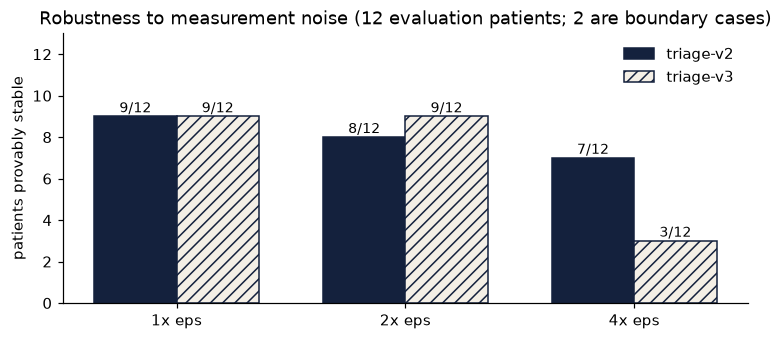

In [9]:
import matplotlib.pyplot as plt
patients = pd.read_csv("data/triage-eval-patients.csv")
EPS1 = {"epsRR": 1, "epsSpo2": 1, "epsSbp": 3, "epsPulse": 2, "epsTemp": 0.1}
DATA = {"patients": "data/triage-eval-patients.idx", "labels": "data/triage-eval-labels.idx"}
per_patient, counts = {}, {}
for m in ("v2", "v3"):
    for scale in (1, 2, 4):
        eps = {k: v * scale for k, v in EPS1.items()}
        r = verify("specs/triage.vcl", f"models/triage-{m}.onnx", ["noiseRobust"], datasets=DATA, parameters=eps, show=False)
        per_patient[(m, scale)] = r["statuses"]; counts[(m, scale)] = r["summary"].get("verified", (0, 12))[0]
        print(f"{m} at {scale}x eps: {counts[(m, scale)]}/12 provably stable  ({r['seconds']:.1f} s)")

tab = patients[["spo2", "sbp", "pulse", "boundary", "note"]].copy()
for k, v in per_patient.items(): tab[f"{k[0]} {k[1]}x"] = ["ok" if s == "verified" else "CE" for s in v]
print("\n" + tab.to_string())

fig, ax = plt.subplots(figsize=(7, 3.2))
xs = np.arange(3); w = 0.36
for i, (m, hatch) in enumerate((("v2", ""), ("v3", "///"))):
    vals = [counts[(m, s)] for s in (1, 2, 4)]
    bars = ax.bar(xs + (i - 0.5) * w, vals, w, label=f"triage-{m}", color=("#14213D" if m == "v2" else "#F4EFE6"), edgecolor="#14213D", hatch=hatch)
    for b, v in zip(bars, vals): ax.text(b.get_x() + b.get_width() / 2, v + 0.2, f"{v}/12", ha="center", fontsize=9)
ax.set_xticks(xs); ax.set_xticklabels(["1x eps", "2x eps", "4x eps"]); ax.set_ylim(0, 13); ax.set_ylabel("patients provably stable")
ax.set_title("Robustness to measurement noise (12 evaluation patients; 2 are boundary cases)"); ax.legend(frameon=False)
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

## 8 · Edit the specification yourself

`specs/triage-exercises.vcl` is a copy of the specification with four exercises appended (search for `TODO`):

1. **Temperature extremes** — ≤ 35.0 °C scores 3 points: write the region so the property says something.
2. **Hypertensive crisis** — SBP ≥ 220 mmHg scores 3 points.
3. **Tighter (and looser) noise boxes** — complete `withinSpo2Noise`; then find the ε at which each model stops being provably stable.
4. **The relaxation trap** — run `hypoxiaNeverLowAnyOxygen` as written (`0 <= x ! o2 <= 1`) on v3 and read the counterexample.

Edit the file (Colab: double-click it in the file browser on the left, or use the cell below), typecheck, verify. `vehicle typecheck` catches most mistakes with a line number.

**Expected output for the cell as given:** the typecheck passes; `temperatureExtremesNeverLow` with the placeholder region is FALSIFIED immediately (the placeholder covers every patient, so of course some are low). After you fix the region to `x ! temp <= 35` it should be VERIFIED on v3.

In [10]:
# Edit specs/triage-exercises.vcl, then run this cell. Change PROP to the exercise you are working on.
PROP = "temperatureExtremesNeverLow"
lines, secs = run_vehicle(["typecheck", "-s", "specs/triage-exercises.vcl"])
print("typecheck:", "OK" if not lines else "\n".join(lines))
if not lines:
    r = verify("specs/triage-exercises.vcl", "models/triage-v3.onnx", [PROP])
    if r["counterexamples"][0]: print(); show_patient(r["counterexamples"][0], models=("v3",))

typecheck: OK
FALSIFIED  temperatureExtremesNeverLow   counterexample: [12.09, 93.5, 92.09, 57.97, 37.37, 0.0, 0.0]
(1.1 s)

parameter  value                          unit  NEWS2 points
       rr  12.09                   breaths/min             0
     spo2  93.50                             %             2
      sbp  92.09                          mmHg             2
    pulse  57.97                     beats/min             0
     temp  37.37                            °C             0
       o2   0.00       1 = supplemental oxygen             0
     cvpu   0.00 1 = new confusion / not alert             0

aggregate NEWS2 score 4; highest single parameter 2  ->  the rule says: LOW
triage-v3 advises: MEDIUM   (scores low/medium/high = [1.3799999952316284, 1.3799999952316284, -0.5899999737739563])  <- TIE: the two highest scores are equal to within rounding; the decision boundary passes through this patient


<details><summary><b>Solutions</b> (click to expand)</summary>

1. `x ! temp <= 35` (and, as a second property, `x ! rr <= 8` or `x ! pulse <= 40` — every "3-point" band is a candidate hard limit). All verified on v3; try v2 and watch the boundary ones fail.
2. `x ! sbp >= 220`. Verified on v3.
3. Replace `d ! spo2 == 0` by `-epsSpo2 <= d ! spo2 <= epsSpo2` and pass `-p epsSpo2:2` (etc.) together with the two `-d` datasets. Patient 10 (SpO₂ 92 %) is falsified at ε ≥ 1 for every model — the rule changes inside the box.
4. The verifier returns a patient with `o2 = 0.37` or similar: the relaxation allows a fractional flag, and the network extrapolates between the two flag values in ways nobody trained for. Pin the flag with `==` and split the property in two (`o2 == 0`, `o2 == 1`), which is what `triage.vcl` does.

</details>

## 9 · This is not tied to one tool

Vehicle compiles a specification to whatever the solver wants. The command below writes the queries for `hypoxiaNeverLow` in **VNN-LIB**, the property format used by every tool in the [International Verification of Neural Networks Competition](https://arxiv.org/abs/2512.19007) (VNN-COMP 2025: eight tools, including Marabou, α,β-CROWN, PyRAT, NeuralSAT, nnenum and NNV). Networks travel as ONNX. Any of those tools could take these two files.

**Expected output:** a folder with one query file per property (`hypoxiaNeverLow-query1.txt`, VNN-LIB 2.0 inside) and its first lines: the network declaration with 7 inputs and 3 outputs, the negated conclusion as `assert`s on the outputs, and the input bounds of the region in clinical units (normalisation is inside the network, so the query is readable).

In [11]:
import glob, shutil
shutil.rmtree("/tmp/vnnlib", ignore_errors=True)
lines, secs = run_vehicle(["compile", "queries", "--format", "VNNLibQueries", "-o", "/tmp/vnnlib",
                           "-s", "specs/triage.vcl", "-n", "triage:models/triage-v3.onnx", "-e", "hypoxiaNeverLow"])
files = sorted(glob.glob("/tmp/vnnlib/*query*.txt"))
print(f"{len(files)} query file(s):", [f.split('/')[-1] for f in files])
if files:
    print("\n" + "\n".join(open(files[0]).read().splitlines()[:32]))
else:
    print("\n".join(lines))

1 query file(s): ['hypoxiaNeverLow-query1.txt']

; WARNING: This file was generated automatically by Vehicle
; and should not be modified manually!
; Metadata:
;  - Vehicle version: 0.27.1
;  - VNN-LIB version: 2.0

(vnnlib-version <2.0>)

; Networks
(declare-network triage
  (declare-input triage_X Real [7])
  (declare-output triage_Y Real [3])
)

; Assertions
(assert (< (+ (- triage_Y[0]) triage_Y[1]) 0.0))
(assert (< (+ (- triage_Y[0]) triage_Y[2]) 0.0))

; Input bounds
(assert (and (<= 4.0 triage_X[0]) (<= triage_X[0] 60.0)))
(assert (and (<= 50.0 triage_X[1]) (<= triage_X[1] 91.0)))
(assert (and (<= 40.0 triage_X[2]) (<= triage_X[2] 250.0)))
(assert (and (<= 20.0 triage_X[3]) (<= triage_X[3] 200.0)))
(assert (and (<= 30.0 triage_X[4]) (<= triage_X[4] 43.0)))
(assert (== triage_X[5] 0.0))
(assert (== triage_X[6] 0.0))


## 10 · Take it to the debate

You have seen three answers a verifier can give — a proof, a counterexample in your own units, a timeout — and one thing it can never give: the decision of what to demand. Pick a scenario card from `docs/debate-role-cards.pdf` (medical triage, authentication, autonomous control), follow the 20-minute protocol in `docs/debate-protocol.pdf`, and fill the decision sheet: *which region, which ε or margin, what happens on a counterexample, who signs.*

Then, for **your own project**, use `docs/spec-your-system-worksheet.pdf`: one requirement as a sentence about *every* input in a region, the same sentence in pseudo-specification, what a counterexample would look like, and what cannot be verified this way (and how you will address it instead).

### How these materials were built (for the curious)
`src/news2.py` re-states the NEWS2 thresholds and defines the class of a real-valued input as the class of its charted (truncated) reading, so every specification threshold sits a full unit away from where the labels change. `src/generate_data.py` samples 40 000 patients (a "typical ward" mixture plus uniform coverage of the whole box, because a verifier explores the whole box). `src/train.py` trains the three models with normalisation folded into the first layer so the ONNX takes clinical units and the solver sees only `Gemm` and `Relu`; v3 adds the property losses and can run a counterexample-guided repair loop against the real verifier. `src/smoke_test.sh` re-verifies everything. Two things that did *not* work are recorded in the field guide: rounding instead of truncating (an infinitely sharp step at 90.5), and repairing counterexamples one at a time (whack-a-mole).

### Further reading
Vehicle tutorial · Katz et al., *Reluplex* (CAV 2017) · VNN-COMP 2025 report (arXiv:2512.19007) · Cordeiro et al., *Neural Network Verification is a Programming Language Challenge* (ESOP 2025) · Sirman et al., *Vancomycert* (SAIV 2026) — full list in `docs/reading-list.pdf`.